<a href="https://colab.research.google.com/github/neaneen/IWS1-Sorting-Slambekova/blob/main/Bubble_Sort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
def bubble_sort(arr):

    n = len(arr)  # определяем длину массива

    for i in range(n):

        swapped = False  #флаг,показывающий были ли перестановки

        for j in range(0, n - i - 1):  #сравнение соседних элементов

            if arr[j] > arr[j + 1]:  # если левый элемент больше

                arr[j], arr[j + 1] = arr[j + 1], arr[j]  # меняем элементы местами

                swapped = True  #произошла перестановка

        if not swapped:  # если за проход перестановок не было, массив уже отсортирован

            break

    return arr

In [26]:
import random  # библиотека для генерации случайных чисел

def random_array(n):  # случайный массив
    return [random.randint(0, 100000) for _ in range(n)]


def sorted_array(n):  # полностью отсортированный массив
    return list(range(n))


def reversed_array(n):  # обратный порядок
    return list(range(n, 0, -1))


def almost_sorted_array(n):  # почти отсортированный массив

    arr = list(range(n))  #отсортированный массив

    swaps = n // 20  #случайные перестановки

    for _ in range(swaps):  # выполняем несколько случайных обменов

        i = random.randint(0, n - 1)  # случайный индекс
        j = random.randint(0, n - 1)  # второй случайный индекс

        arr[i], arr[j] = arr[j], arr[i]  # меняем элементы местами

    return arr  # возвращаем массив

In [27]:
import time  # модуль для измерения времени


def measure_bubble(arr):  # измерение bubble sort

    start = time.perf_counter()  #начало

    bubble_sort(arr)  # запускаем

    end = time.perf_counter()  # конец

    return end - start  # возвращаем время

In [28]:
def average_time(generator, n, runs=5):  # функция усреднения времени

    times = []  # список для хранения

    for _ in range(runs):  # запускаем несколько раз

        arr = generator(n)  # создаём новый массив

        arr_copy = arr.copy()  # копируем

        t = measure_bubble(arr_copy)  # измеряем время

        times.append(t)  # сохраняем результат

    return sum(times) / len(times)  # возвращаем среднее время

In [29]:
sizes = [1000, 5000, 10000, 50000]

random_times = []
sorted_times = []
reversed_times = []
almost_sorted_times = []

for n in sizes:
    t_random = average_time(random_array, n)
    t_sorted = average_time(sorted_array, n)
    t_reversed = average_time(reversed_array, n)
    t_almost = average_time(almost_sorted_array, n)

    random_times.append(t_random)
    sorted_times.append(t_sorted)
    reversed_times.append(t_reversed)
    almost_sorted_times.append(t_almost)

    print("Размер:", n)
    print("Случайный:", t_random)
    print("Отсортированный:", t_sorted)
    print("Обратный:", t_reversed)
    print("Почти отсортированный:", t_almost)
    print()

Размер: 1000
Случайный: 0.03455927120030537
Отсортированный: 3.66319996828679e-05
Обратный: 0.04243629479988158
Почти отсортированный: 0.020404096400307027

Размер: 5000
Случайный: 1.0825864010002988
Отсортированный: 0.00020222799976181703
Обратный: 1.2548424138001792
Почти отсортированный: 0.6643596389996673

Размер: 10000
Случайный: 4.089607706400057
Отсортированный: 0.0006952036001166562
Обратный: 5.128649740999935
Почти отсортированный: 2.3871991493999305

Размер: 50000
Случайный: 124.3926399076001
Отсортированный: 0.002673493400106963
Обратный: 139.00482101180006
Почти отсортированный: 67.68148655919995



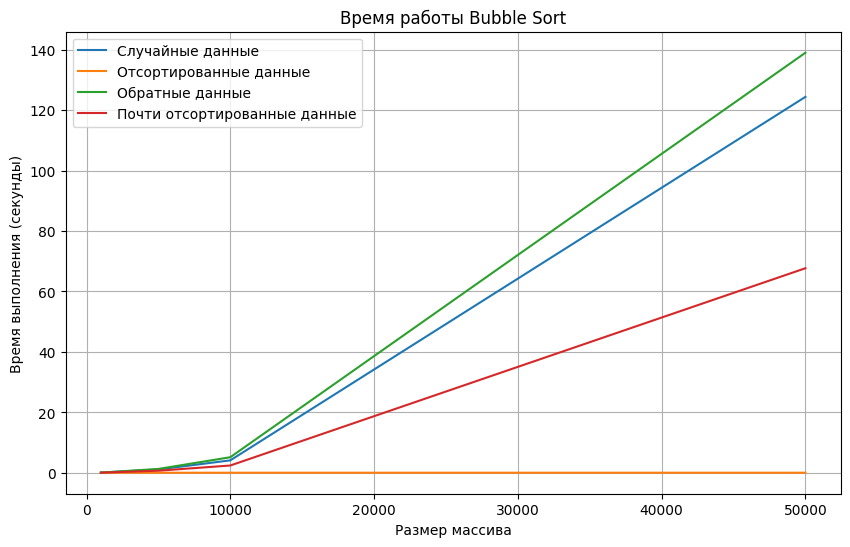

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, random_times, label="Случайные данные")
plt.plot(sizes, sorted_times, label="Отсортированные данные")
plt.plot(sizes, reversed_times, label="Обратные данные")
plt.plot(sizes, almost_sorted_times, label="Почти отсортированные данные")

plt.xlabel("Размер массива")
plt.ylabel("Время выполнения (секунды)")
plt.title("Время работы Bubble Sort")

plt.legend()
plt.grid(True)
plt.show()